In [1]:
import xgboost
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import os
import glob

In [2]:
import mpl_fontkit as fk

fk.install("Roboto Condensed")
fk.set_font("Roboto Condensed")
plt.rcParams["figure.dpi"] = 300

Font name: `Roboto Condensed`


In [5]:
FN = "../../data/dump_features/cs/cs_foot_pos_1.csv"

In [6]:
df = pd.read_csv(FN)
df

,sample_id,class_label,N,V,P,A,D,J,R,T,C,I
0,amphibrach_1,amphibrach,-1.398171,-1.035007,0.679462,-0.675976,1.032867,1.871551,-1.271226,-0.775370,0.419353,1.821604
1,amphibrach_2,amphibrach,-2.764653,-1.200757,2.442688,-0.908474,1.506672,1.651361,-1.206802,1.759958,-1.324925,2.142924
2,amphibrach_3,amphibrach,-1.992548,-2.097517,1.482820,-1.441757,1.519262,1.456189,-0.392917,2.036137,1.199120,2.689896
3,amphibrach_4,amphibrach,-2.131431,-0.976270,1.309184,-1.449818,1.837505,1.167177,-0.738172,0.883082,1.474322,1.951236
4,amphibrach_5,amphibrach,-1.003886,-0.134309,0.195417,-1.192131,0.592985,1.717104,-1.394776,0.777889,-1.127248,1.704419
...,...,...,...,...,...,...,...,...,...,...,...,...
165,trochee_46,trochee,-0.214511,0.996838,0.538660,-1.474479,0.255900,-0.814651,1.074546,0.802587,0.565182,-1.460869
166,trochee_47,trochee,0.442553,0.463272,1.252812,-0.844273,-0.517018,-1.135148,0.233022,1.579421,-0.358730,-0.301976
167,trochee_48,trochee,-0.521623,0.819662,0.840110,1.471310,-1.070037,-0.514984,-0.735213,0.020892,0.268007,0.391884
168,trochee_49,trochee,1.235684,0.442873,-0.786817,-0.344002,-0.028488,-0.792112,-0.173075,-1.134445,1.444555,0.361324


In [7]:
X = df.iloc[:, 2:]
y, y_uniques = df.class_label.factorize()

In [ ]:
# xgb = xgboost.XGBClassifier(
#     colsample_bytree=0.5,
#     colsample_bylevel=0.5,
#     colsample_bynode=0.5,
#     objective="multi:softprob",
#     num_class=len(y_uniques),
#     nthread=10,
#     seed=42,
# )

# sss = StratifiedShuffleSplit(n_splits=25, test_size=0.1, random_state=42)
# sss_scores = cross_validate(xgb, X, y, cv=sss)
# print(f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s")
# print(
#     f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n"
# )
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, random_state=42, test_size=0.1, stratify=y
# )
# xgb.fit(X_train, y_train)
# ConfusionMatrixDisplay.from_estimator(
#     xgb, X_test, y_test, display_labels=list(y_uniques)
# )
# plt.title(
#     f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s\n"
#     + f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n",
#     loc="left",
# )
# plt.show()

Mean fit time: 0.20s
Accuracy mean: 88.47%, median: 88.24%



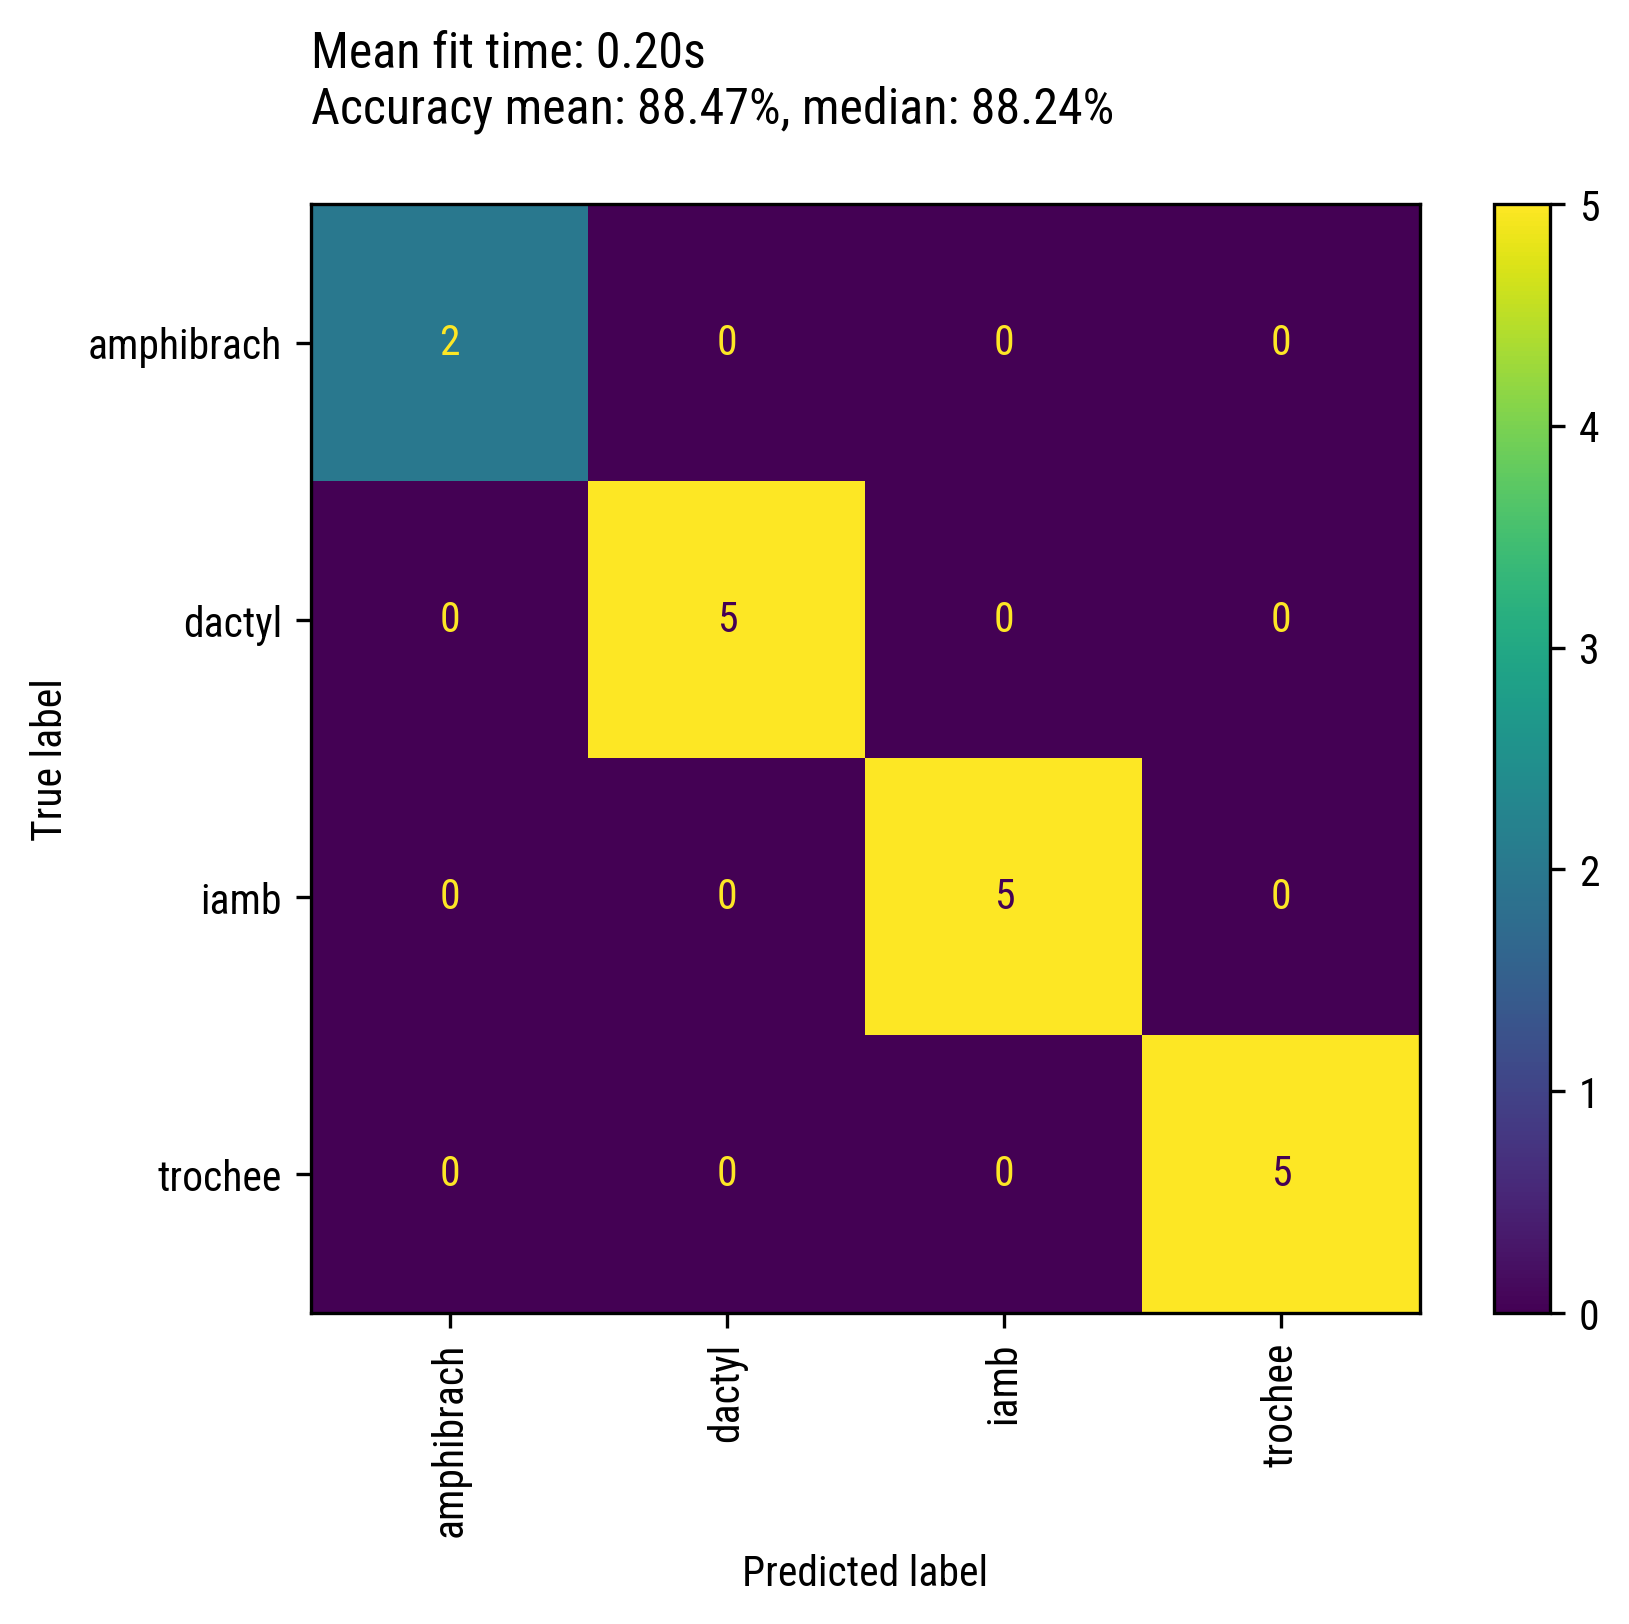

In [8]:
rfc = RandomForestClassifier()

sss = StratifiedShuffleSplit(n_splits=25, test_size=0.1, random_state=42)
sss_scores = cross_validate(rfc, X, y, cv=sss)
print(f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s")
print(
    f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n"
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.1, stratify=y
)
rfc.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(
    rfc, X_test, y_test, display_labels=list(y_uniques)
)
plt.title(
    f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s\n"
    + f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n",
    loc="left",
)
plt.xticks(rotation=90)

plt.savefig(f"{os.path.splitext(os.path.basename(FN))[0]}_confusion.png")
plt.show()

In [9]:
rfc.fit(X, y)
# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer_rfc = shap.Explainer(rfc)
shap_values_rfc = explainer_rfc(X)

In [12]:
# xgb.fit(X, y)
# # explain the model's predictions using SHAP
# # (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
# explainer_xgb = shap.Explainer(xgb)
# shap_values_xgb = explainer_xgb(X)

NameError: name 'xgb' is not defined

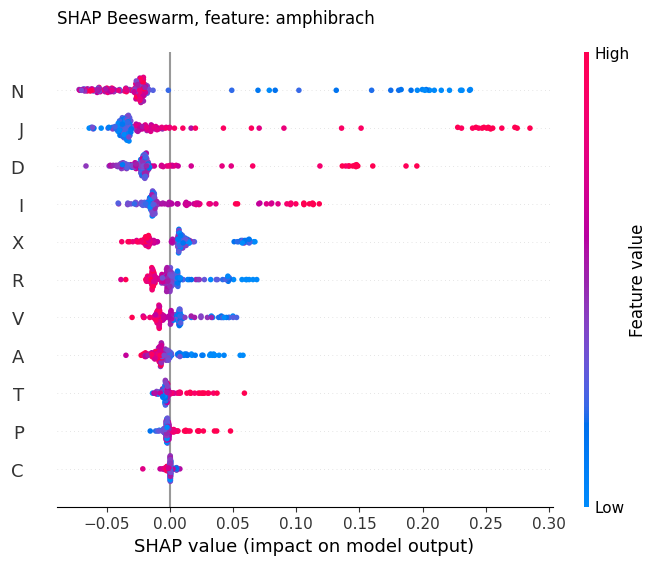

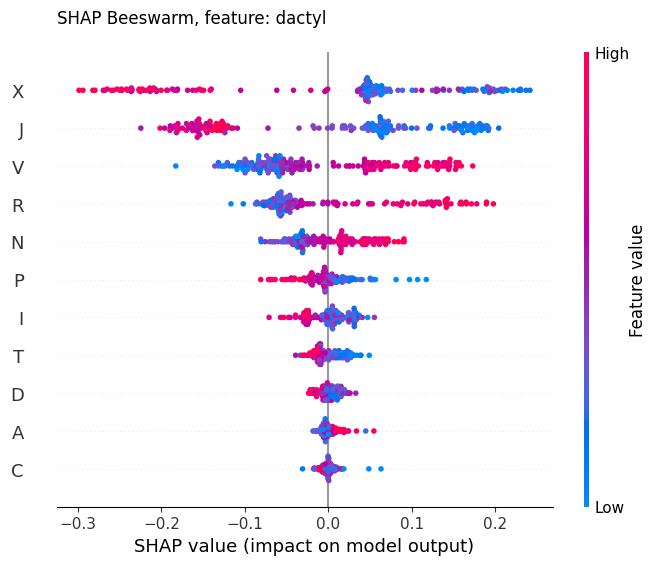

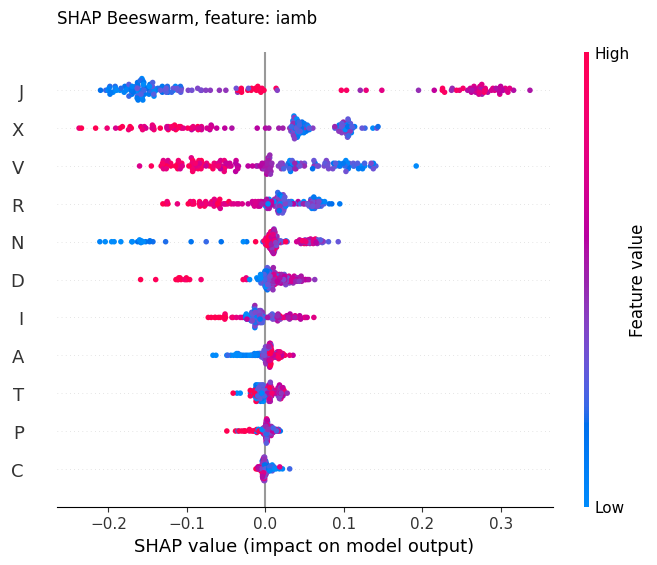

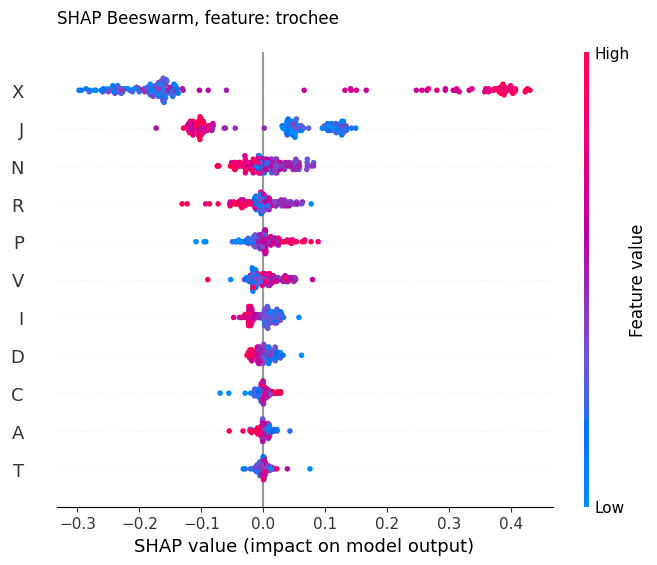

In [15]:
for target_class in y_uniques:
    shap.plots.beeswarm(
        shap_values_rfc[..., y_uniques.get_loc(target_class)],
        max_display=20,
        show=False,
    )
    plt.title(f"SHAP Beeswarm, feature: {target_class}\n", loc="left")
    plt.savefig(
        f"{os.path.splitext(os.path.basename(FN))[0]}_beeswarm_{target_class}.png"
    )
    plt.show()

In [16]:
vals = [shap_values_rfc.values[:, :, i] for i in range(shap_values_xgb.shape[2])]
shap.summary_plot(
    vals,
    X,
    class_names=y_uniques,
    plot_type="bar",
    show=False,
    max_display=20,
)
plt.xlabel("")
plt.title(f"Multi-class feature importance\n")
plt.savefig(
    f"{os.path.splitext(os.path.basename(FN))[0]}_importance_multiclass.png",
    bbox_inches="tight",
)
plt.show()

NameError: name 'shap_values_xgb' is not defined

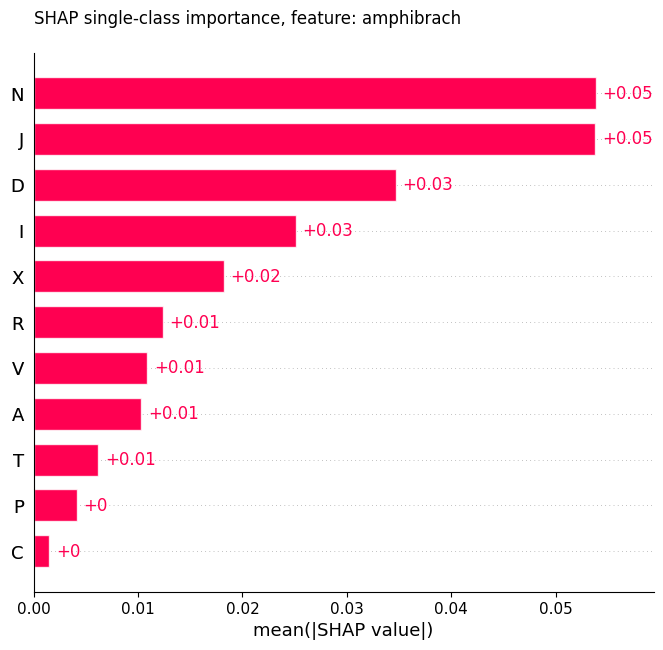

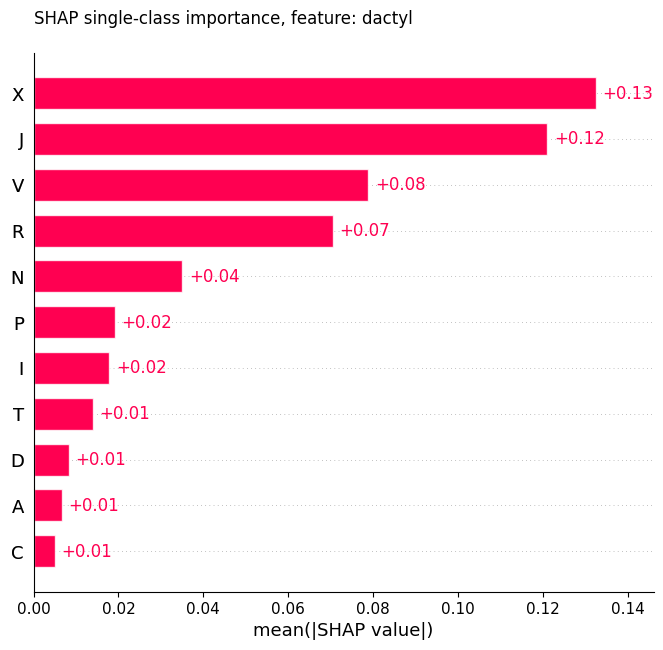

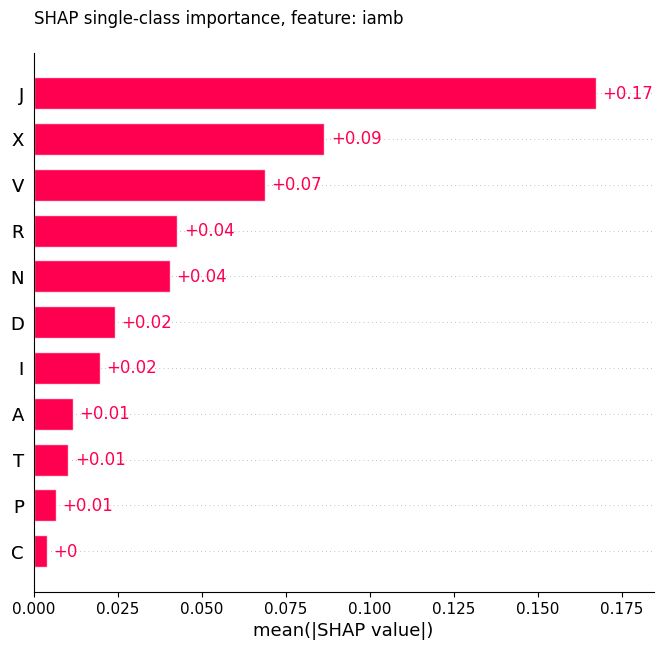

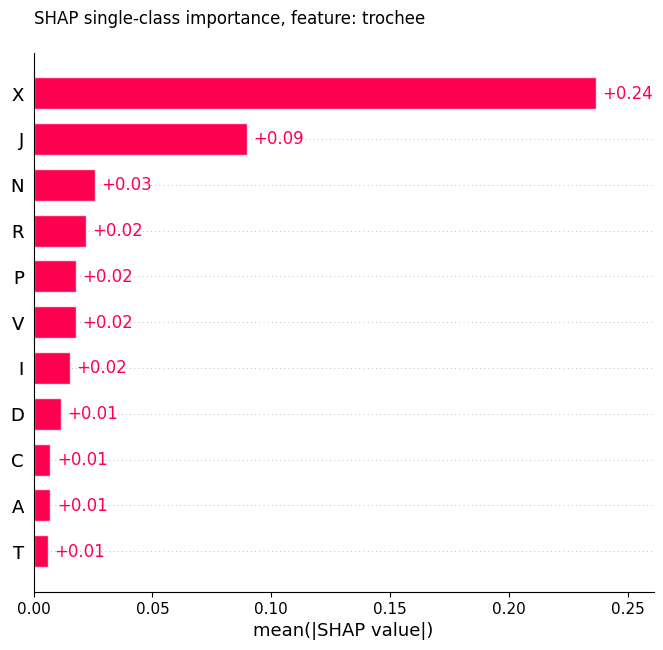

In [17]:
for target_class in y_uniques:
    shap.plots.bar(
        shap_values_rfc[..., y_uniques.get_loc(target_class)],
        max_display=20,
        show=False,
    )
    plt.title(f"SHAP single-class importance, feature: {target_class}\n", loc="left")
    plt.savefig(
        f"{os.path.splitext(os.path.basename(FN))[0]}_importance_{target_class}.png"
    )
    plt.show()

In [11]:
def plot_train_rfc(fn, X, y, y_uniques):
    rfc = RandomForestClassifier()

    sss = StratifiedShuffleSplit(n_splits=25, test_size=0.1, random_state=42)
    sss_scores = cross_validate(rfc, X, y, cv=sss)
    print(f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s")
    print(
        f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n"
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=42, test_size=0.1, stratify=y
    )
    rfc.fit(X_train, y_train)
    ConfusionMatrixDisplay.from_estimator(
        rfc, X_test, y_test, display_labels=list(y_uniques)
    )
    plt.title(
        f"{fn}\n"
        + f"Mean fit time: {sss_scores["fit_time"].mean():.2f}s\n"
        + f"Accuracy mean: {sss_scores['test_score'].mean():.2%}, median: {np.median(sss_scores['test_score']):.2%}\n",
        loc="left",
    )
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(
        f"{os.path.splitext(os.path.basename(fn))[0]}_confusion.png",
        bbox_inches="tight",
    )
    plt.close()


def plot_beeswarms(fn, svv, y_uniques):
    for target_class in y_uniques:
        shap.plots.beeswarm(
            svv[..., y_uniques.get_loc(target_class)],
            max_display=20,
            show=False,
        )
        plt.title(f"{fn}\n" + f"SHAP Beeswarm, feature: {target_class}\n", loc="left")
        plt.savefig(
            f"{os.path.splitext(os.path.basename(fn))[0]}_beeswarm_{target_class}.png",
            bbox_inches="tight",
        )
        plt.tight_layout()
        plt.close()


def plot_singleclass_importances(fn, svv, y_uniques):
    for target_class in y_uniques:
        shap.plots.bar(
            svv[..., y_uniques.get_loc(target_class)],
            max_display=20,
            show=False,
        )
        plt.title(
            f"{fn}\n" + f"SHAP single class importances, feature: {target_class}\n",
            loc="left",
        )
        plt.savefig(
            f"{os.path.splitext(os.path.basename(fn))[0]}_importances_{target_class}.png",
            bbox_inches="tight",
        )
        plt.tight_layout()
        plt.close()


def plot_multiclass_importances(fn, svv, X, y_uniques):
    vals = [svv.values[:, :, i] for i in range(svv.shape[2])]
    shap.summary_plot(
        vals,
        X,
        class_names=y_uniques,
        plot_type="bar",
        show=False,
        max_display=20,
    )
    plt.title(f"{fn}\n" + f"Multi-class feature importance\n", loc="left")
    plt.savefig(
        f"{os.path.splitext(os.path.basename(fn))[0]}_importance_multiclass.png",
        bbox_inches="tight",
    )
    plt.tight_layout()
    plt.close()


def do_plots(fn: str):

    df = pd.read_csv(fn)
    X = df.iloc[:, 2:200]
    y, y_uniques = df.class_label.factorize()

    plot_train_rfc(fn, X, y, y_uniques)

    rfc.fit(X, y)
    # explain the model's predictions using SHAP
    # (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
    explainer_rfc = shap.Explainer(rfc)
    shap_values_rfc = explainer_rfc(X)

    plot_beeswarms(fn, shap_values_rfc, y_uniques)
    plot_singleclass_importances(fn, shap_values_rfc, y_uniques)
    plot_multiclass_importances(fn, shap_values_rfc, X, y_uniques)

In [14]:
do_plots("../../data/dump_features/cs_foot_all.csv")

Mean fit time: 0.22s
Accuracy mean: 100.00%, median: 100.00%



In [95]:
for fn in glob.glob("*/*.csv"):
    do_plots(fn)

Mean fit time: 0.07s
Accuracy mean: 100.00%, median: 100.00%

Mean fit time: 0.07s
Accuracy mean: 100.00%, median: 100.00%

Mean fit time: 0.12s
Accuracy mean: 61.49%, median: 61.02%

Mean fit time: 0.05s
Accuracy mean: 95.06%, median: 94.12%

Mean fit time: 0.05s
Accuracy mean: 100.00%, median: 100.00%

Mean fit time: 0.22s
Accuracy mean: 88.88%, median: 89.83%

Mean fit time: 0.04s
Accuracy mean: 100.00%, median: 100.00%

Mean fit time: 0.09s
Accuracy mean: 97.15%, median: 96.61%

Mean fit time: 0.05s
Accuracy mean: 100.00%, median: 100.00%

Mean fit time: 0.08s
Accuracy mean: 83.86%, median: 83.05%

Mean fit time: 0.07s
Accuracy mean: 98.35%, median: 100.00%

Mean fit time: 0.06s
Accuracy mean: 73.18%, median: 70.59%

Mean fit time: 0.25s
Accuracy mean: 72.75%, median: 72.88%

Mean fit time: 0.13s
Accuracy mean: 89.83%, median: 89.83%

Mean fit time: 0.15s
Accuracy mean: 40.07%, median: 38.98%

Mean fit time: 0.29s
Accuracy mean: 97.08%, median: 96.61%

Mean fit time: 0.09s
Accuracy